# Five-player Cournot game: evolving parameters and particle values

This deterministic example advances the NN parameters and the particle map values at every step. The evolving NN supplies the tangent Jacobian; the particle values are stored and advanced separately. There are no resets or NN refits.

With $b=2$, $\mu=7/4$, and $s_i=\sum_{j\ne i}x_j$, the game velocity is

$$F_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right).$$

Initial particles are uniform on $[0,1]^5$. Run all cells for the point clouds in $(x_1,x_2)$, $(x_2,x_3)$, $(x_3,x_4)$, and $(x_4,x_5)$, followed by the projection-error trajectory.

[Open in Colab](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_b2_mu7_4_parameter_evolving_dtb.ipynb)

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

# Use the existing helpers locally, or obtain them when running in Colab.
module_files = ('dtb.py', 'run_game_dtb.py')
module_dir = next((p for p in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
                   if all((p / name).is_file() for name in module_files)), None)
if module_dir is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    module_dir = repo / 'DTB_Game_Ver2'
sys.path.insert(0, str(module_dir.resolve()))

from dtb import flat_params, write_flat_into_model
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices

## Parameters

The residual tanh MLP and particle map both start at the identity. Select 128 parameter coordinates at each step, compute the tangent projection, and use the same coefficients to update those parameters and the particle values.

In [2]:
SEED = 0
DIM = 5
COURNOT_B = 2.0
COURNOT_MU = 7 / 4
N_PARTICLES = 3000

H = 0.001
T_FINAL = 2.5
SNAPSHOT_TIMES = (0.0, 0.25, 0.5, T_FINAL)
WIDTH, DEPTH = 16, 2
BASIS_SIZE = 128
SVD_RTOL = 1e-6  # Retain singular values above SVD_RTOL * s_max.
JACOBIAN_CHUNK = 256

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))


def game_velocity(x):
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1 - rivals)).clamp_min(0.0)
    return 2 * COURNOT_B * (best_response - x)

## Evolve parameters and particles separately

Keep the reference labels $z_i$ fixed and initialize $x_i^0=z_i$. At step $k$, select parameter coordinates $S_k$ and evaluate

$$J_i^k=\partial_{\theta_{S_k}}T_{\theta_k}(z_i),\qquad g_i^k=F(x_i^k).$$

For $A=J^k/\sqrt N=U\Sigma V^\top$ and $y=\operatorname{vec}(g^k)/\sqrt N$, retain $s_\ell>\texttt{SVD\_RTOL}\,s_{\max}$ and solve

$$\alpha^k=V_{\rm keep}\Sigma_{\rm keep}^{-1}U_{\rm keep}^\top y.$$

Update both states using this same old-step Jacobian and coefficient vector:

$$\theta_{k+1}=\theta_k+h_k E_{S_k}\alpha^k,
\qquad x_i^{k+1}=x_i^k+h_kJ_i^k\alpha^k.$$

Here $E_{S_k}$ inserts the $m$ coefficients into the selected entries of the full parameter vector; other entries are unchanged at that step. The parameter increment is $h_k\alpha^k$ on $S_k$: $J^k\alpha^k$ has particle-space dimensions and is the increment direction for $X$.

**The new particle values are never replaced by $T_{\theta_{k+1}}(z_i)$.** The next Jacobian uses $\theta_{k+1}$ at the fixed labels, while the next game velocity uses the independently accumulated $x_i^{k+1}$. No reset or refit is performed.

The error curve records $\|J^k\alpha^k-g^k\|/\sqrt N$ at the start of each step. Every snapshot comes from the accumulated particle values.

In [3]:
# Rerunning this cell restarts both states from the identity map.
torch.manual_seed(SEED)
basis_generator = torch.Generator().manual_seed(SEED + 1)
z = torch.rand(N_PARTICLES, DIM, generator=torch.Generator().manual_seed(SEED),
               dtype=DTYPE).to(DEVICE)
x = z.clone()  # Independently accumulated particle map X^k(z_i).
model = ResidualMLPMap(dim=DIM, width=WIDTH, depth=DEPTH,
                       activation='tanh', dtype=DTYPE).to(DEVICE)
theta, structure, _ = flat_params(model)

snapshot_times = np.unique(np.round(SNAPSHOT_TIMES, 12))
times = np.unique(np.round(np.r_[np.arange(0, T_FINAL, H), snapshot_times, T_FINAL], 12))
projection_times = times[:-1]
projection_error = []
clouds = {0.0: x.cpu().numpy().copy()}

for k, t in enumerate(projection_times):
    indices = torch.randperm(theta.numel(), generator=basis_generator)
    selected = indices[:BASIS_SIZE].sort().values.to(DEVICE)
    _, _, J_flat = game_dtb_basis_matrices(
        theta, selected, z, model, structure, chunk=JACOBIAN_CHUNK)
    J_flat = J_flat.detach()

    velocity = game_velocity(x)
    A = J_flat / np.sqrt(N_PARTICLES)
    target = velocity.reshape(-1) / np.sqrt(N_PARTICLES)
    U, s, Vh = torch.linalg.svd(A, full_matrices=False)
    keep = s > SVD_RTOL * s[0]
    alpha = Vh[keep].T @ ((U[:, keep].T @ target) / s[keep])
    tangent_velocity = (J_flat @ alpha).reshape_as(x)
    error = (tangent_velocity - velocity).square().sum(dim=1).mean().sqrt()
    if not torch.isfinite(error):
        raise FloatingPointError(f'Nonfinite tangent projection at t={t:g}.')
    projection_error.append(error.item())

    next_time = float(times[k + 1])
    h = next_time - float(t)
    # Both increments use J(theta_k, z) and alpha_k computed above.
    theta[selected] += h * alpha
    x = (x + h * tangent_velocity).detach()
    if not torch.isfinite(theta).all() or not torch.isfinite(x).all():
        raise FloatingPointError(f'Nonfinite state at t={next_time:g}.')

    if next_time in snapshot_times:
        clouds[next_time] = x.cpu().numpy().copy()

# Synchronize the model for later inspection; this does not change x.
write_flat_into_model(model, theta, structure)
projection_error = np.asarray(projection_error)

## Point-cloud projections

Rows show the four adjacent coordinate pairs; columns show physical time. All particles are displayed, with common axis limits across the figure.

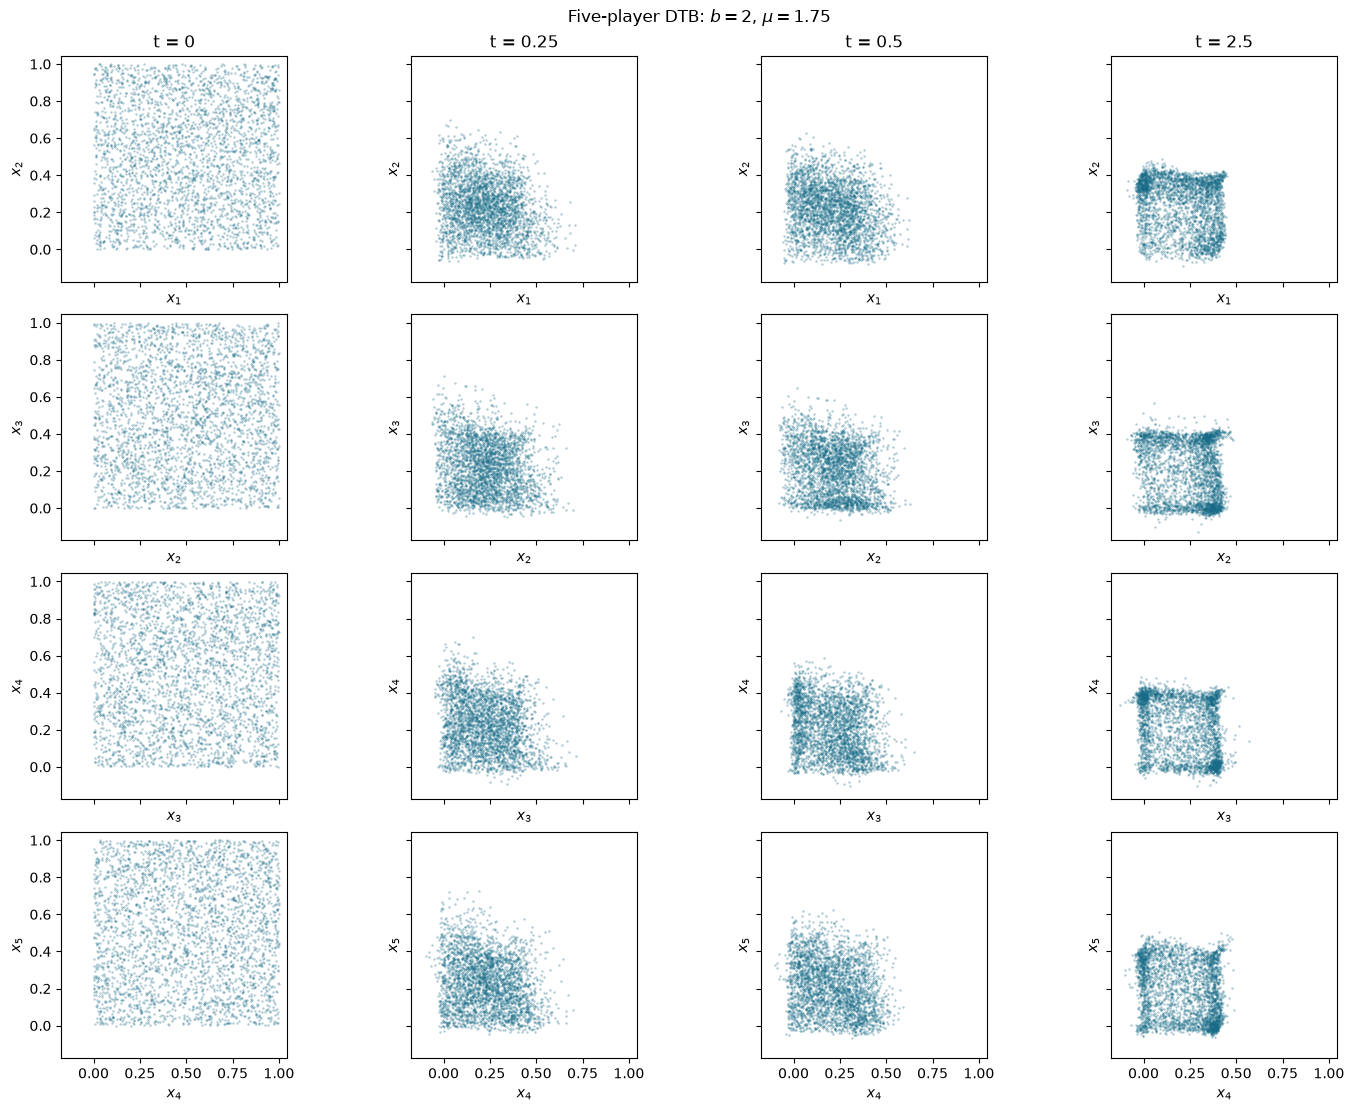

In [4]:
pairs = ((0, 1), (1, 2), (2, 3), (3, 4))
fig, axes = plt.subplots(4, len(clouds), figsize=(3.5 * len(clouds), 11),
                         sharex=True, sharey=True, squeeze=False, layout='constrained')
lo = min(points.min() for points in clouds.values())
hi = max(points.max() for points in clouds.values())
padding = 0.04 * max(hi - lo, 1e-6)

for row, (i, j) in enumerate(pairs):
    for col, (t, points) in enumerate(clouds.items()):
        ax = axes[row, col]
        ax.scatter(points[:, i], points[:, j], s=3, alpha=0.35,
                   color='#176b87', linewidths=0, rasterized=True)
        ax.set(xlabel=fr'$x_{i + 1}$', ylabel=fr'$x_{j + 1}$',
               xlim=(lo - padding, hi + padding), ylim=(lo - padding, hi + padding))
        ax.set_aspect('equal', adjustable='box')
        if row == 0:
            ax.set_title(f't = {t:g}')
fig.suptitle(fr'Five-player DTB: $b={COURNOT_B:g}$, $\mu={COURNOT_MU:g}$')
plt.show()

## Projection-error trajectory

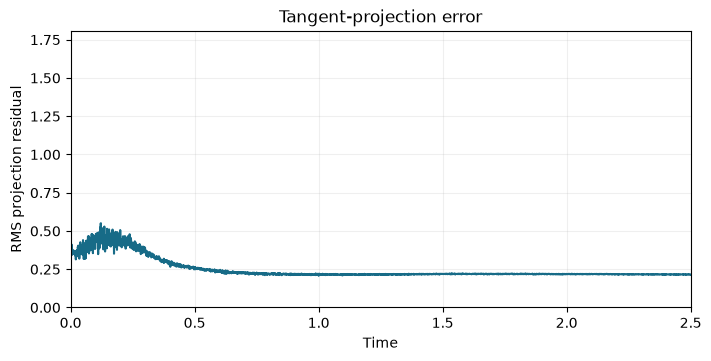

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
ax.plot(projection_times, projection_error, color='#176b87', linewidth=1.5)
ax.set(xlabel='Time', ylabel='RMS projection residual',
       title='Tangent-projection error', xlim=(0, T_FINAL), ylim=(0, None))
ax.grid(alpha=0.2)
plt.show()